In [2]:

import cv2

In [7]:
!pip install matplotlib



In [9]:
!pip install opencv-python

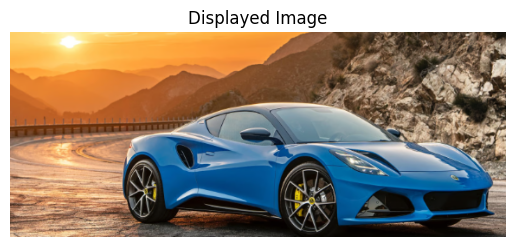

In [11]:
import cv2
import matplotlib.pyplot as plt

# Updated image path
image_path = "/content/car.png"

# Read image (BGR format)
car_img_bgr = cv2.imread(image_path)

# Convert BGR to RGB for correct display
car_img_rgb = cv2.cvtColor(car_img_bgr, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(car_img_rgb)
plt.title('Displayed Image')
plt.axis('off')
plt.show()

In [13]:
import cv2

# Updated path
cb_img = cv2.imread("/content/car.png", cv2.IMREAD_GRAYSCALE)

print(cb_img)

[[215 215 216 ...  28  21  21]
 [215 215 215 ...  21  21  21]
 [214 215 215 ...  21  21  21]
 ...
 [190 203 207 ...  64  82  78]
 [198 192 207 ...  68  70  74]
 [203 197 202 ...  64  46  64]]


In [15]:

print("Shape of the image: ", cb_img.shape)
print("Data type of the image: ", cb_img.dtype)
print("Size of the image: ", cb_img.size)

Shape of the image:  (237, 573)
Data type of the image:  uint8
Size of the image:  135801


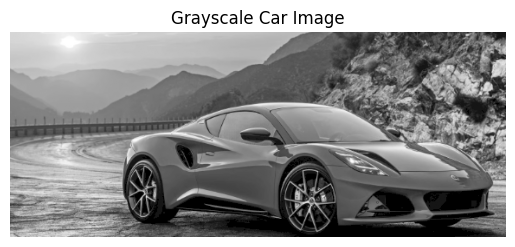

In [17]:
plt.imshow(cb_img, cmap='gray')
plt.title('Grayscale Car Image')
plt.axis('off')
plt.show()

In [18]:
import cv2

# Updated path
cb_img = cv2.imread("/content/car.png", cv2.IMREAD_GRAYSCALE)

# Safety check
if cb_img is None:
    print("Image not found. Check the path!")
else:
    print("Shape of the image: ", cb_img.shape)
    print("Size of the image: ", cb_img.size)
    print("Data type of the image: ", cb_img.dtype)

Shape of the image:  (237, 573)
Size of the image:  135801
Data type of the image:  uint8


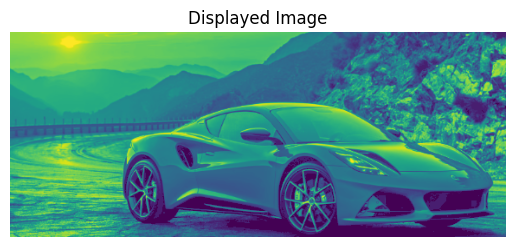

In [19]:

import matplotlib.pyplot as plt

plt.imshow(cb_img)
plt.axis('off')
plt.title('Displayed Image')
plt.show()

Original image shape: (237, 573, 3)
Reversed channels image shape: (237, 573, 3)


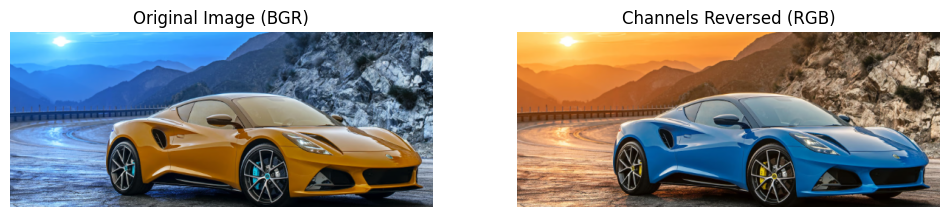

In [20]:
import cv2
import matplotlib.pyplot as plt

# Read the image
car_img = cv2.imread("/content/car.png")

# Safety check
if car_img is None:
    print("Image not found. Check the path!")
else:
    # Convert BGR → RGB
    car_img_rgb = cv2.cvtColor(car_img, cv2.COLOR_BGR2RGB)

    print("Original image shape:", car_img.shape)
    print("Reversed channels image shape:", car_img_rgb.shape)

    # Display both images
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(car_img)  # Will look incorrect (BGR)
    plt.title('Original Image (BGR)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(car_img_rgb)  # Correct colors
    plt.title('Channels Reversed (RGB)')
    plt.axis('off')

    plt.show()

Car Image Shape: (237, 573, 3)
Car Image Size: 407403
Car Image Data Type: uint8
Chessboard Shape: (445, 449)
Chessboard Size: 199805
Chessboard Data Type: uint8


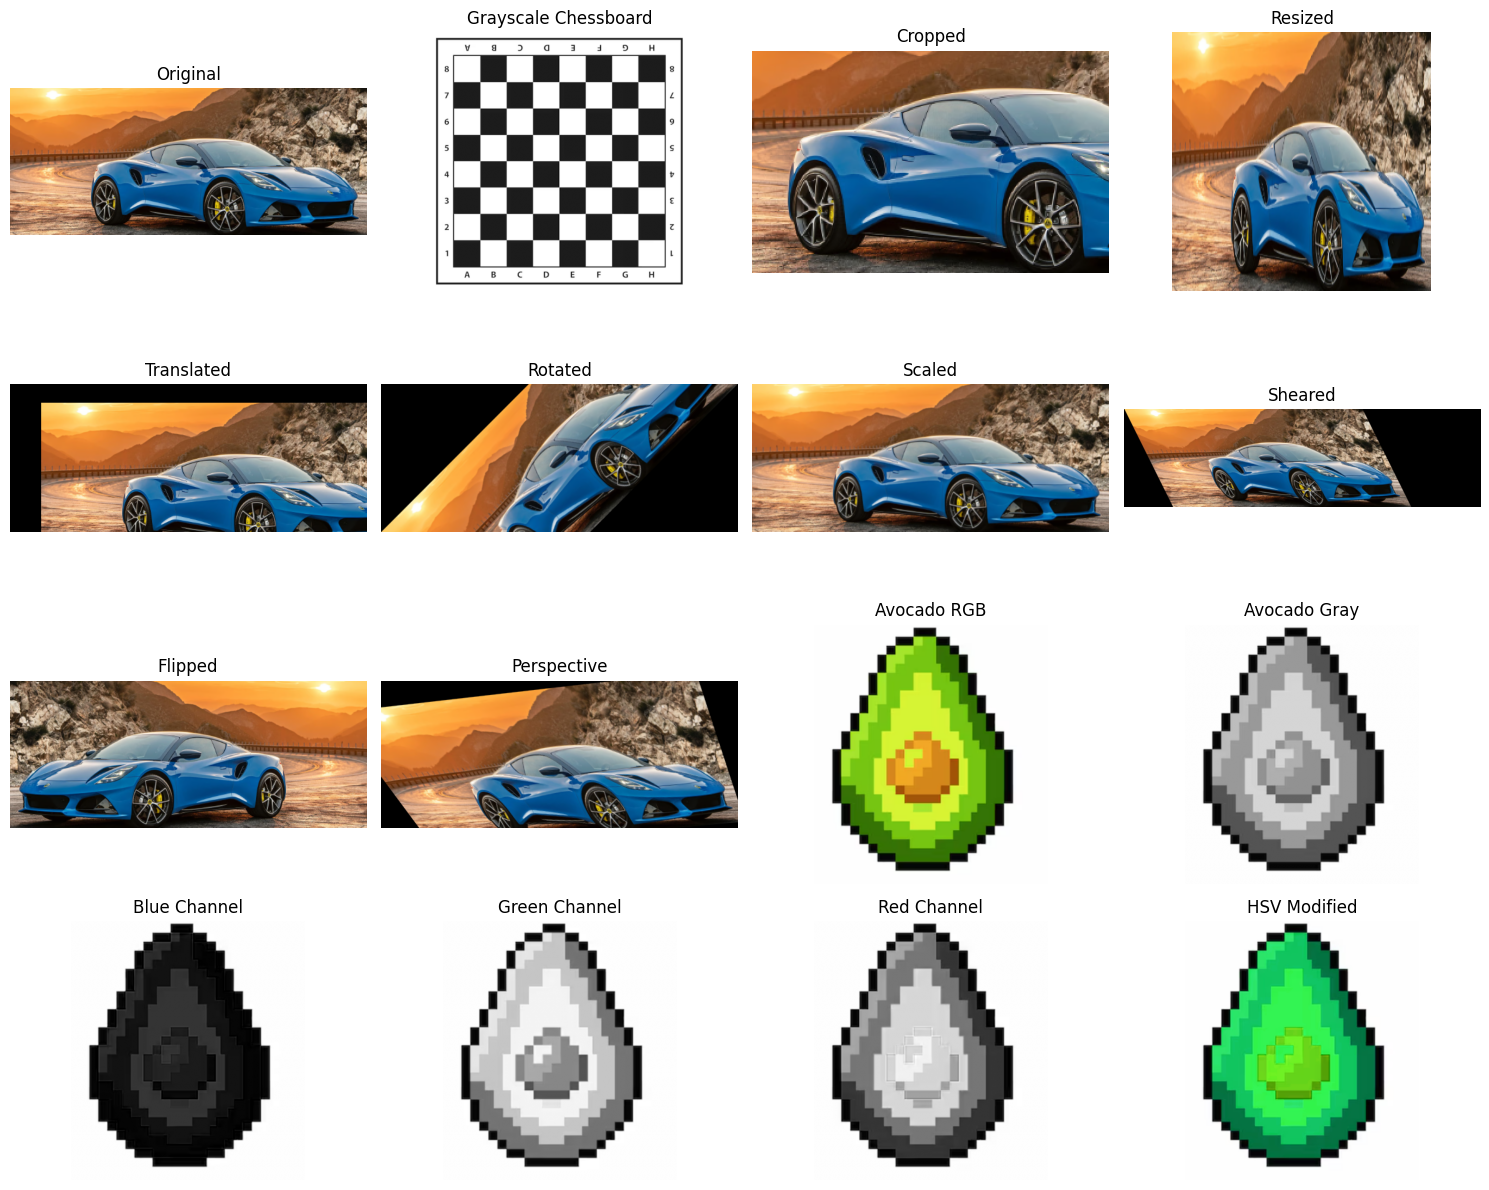

Processed image saved!


In [1]:
# Install libraries (run once)
!pip install opencv-python matplotlib

# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# IMAGE PATHS
# =========================
car_path = "/content/car.png"
chess_path = "/content/chessboard.png"
avocado_path = "/content/avacado.png"

# =========================
# LOAD IMAGES
# =========================
car_img = cv2.imread(car_path)
cb_img = cv2.imread(chess_path, cv2.IMREAD_GRAYSCALE)
avocado_img = cv2.imread(avocado_path)

# Check images
if car_img is None or cb_img is None or avocado_img is None:
    print("Error: One or more images not found!")
    exit()

# =========================
# BASIC PROPERTIES
# =========================
print("Car Image Shape:", car_img.shape)
print("Car Image Size:", car_img.size)
print("Car Image Data Type:", car_img.dtype)

print("Chessboard Shape:", cb_img.shape)
print("Chessboard Size:", cb_img.size)
print("Chessboard Data Type:", cb_img.dtype)

# =========================
# COLOR CONVERSION
# =========================
car_rgb = cv2.cvtColor(car_img, cv2.COLOR_BGR2RGB)
avocado_rgb = cv2.cvtColor(avocado_img, cv2.COLOR_BGR2RGB)
avocado_gray = cv2.cvtColor(avocado_img, cv2.COLOR_BGR2GRAY)

# =========================
# TRANSFORMATIONS
# =========================

# Cropping
cropped = car_img[50:300, 100:400]

# Resize
resized = cv2.resize(car_img, (300, 300))

# Translation
rows, cols = car_img.shape[:2]
M_trans = np.float32([[1, 0, 50], [0, 1, 30]])
translated = cv2.warpAffine(car_img, M_trans, (cols, rows))

# Rotation
center = (cols // 2, rows // 2)
M_rot = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(car_img, M_rot, (cols, rows))

# Scaling
scaled = cv2.resize(car_img, None, fx=1.5, fy=1.5)

# Shearing
M_shear = np.float32([[1, 0.5, 0], [0, 1, 0]])
sheared = cv2.warpAffine(car_img, M_shear, (int(cols * 1.5), rows))

# Reflection
flipped = cv2.flip(car_img, 1)

# Perspective Transform
pts1 = np.float32([[50, 50], [cols-50, 50], [50, rows-50], [cols-50, rows-50]])
pts2 = np.float32([[10, 100], [cols-100, 50], [100, rows-10], [cols-50, rows-50]])
M_persp = cv2.getPerspectiveTransform(pts1, pts2)
perspective = cv2.warpPerspective(car_img, M_persp, (cols, rows))

# =========================
# CHANNEL OPERATIONS
# =========================
b, g, r = cv2.split(avocado_img)
merged = cv2.merge((b, g, r))
merged_rgb = cv2.cvtColor(merged, cv2.COLOR_BGR2RGB)

# HSV Manipulation
hsv = cv2.cvtColor(avocado_img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
h_new = (h + 30) % 180
hsv_new = cv2.merge((h_new, s, v))
final_img = cv2.cvtColor(hsv_new, cv2.COLOR_HSV2RGB)

# =========================
# DISPLAY ALL RESULTS
# =========================
plt.figure(figsize=(15, 12))

images = [
    ("Original", car_rgb),
    ("Grayscale Chessboard", cb_img),
    ("Cropped", cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)),
    ("Resized", cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)),
    ("Translated", cv2.cvtColor(translated, cv2.COLOR_BGR2RGB)),
    ("Rotated", cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)),
    ("Scaled", cv2.cvtColor(scaled, cv2.COLOR_BGR2RGB)),
    ("Sheared", cv2.cvtColor(sheared, cv2.COLOR_BGR2RGB)),
    ("Flipped", cv2.cvtColor(flipped, cv2.COLOR_BGR2RGB)),
    ("Perspective", cv2.cvtColor(perspective, cv2.COLOR_BGR2RGB)),
    ("Avocado RGB", avocado_rgb),
    ("Avocado Gray", avocado_gray),
    ("Blue Channel", b),
    ("Green Channel", g),
    ("Red Channel", r),
    ("HSV Modified", final_img)
]

for i, (title, img) in enumerate(images):
    plt.subplot(4, 4, i+1)
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()

# =========================
# SAVE IMAGE
# =========================
cv2.imwrite("/content/sample_data/output_image.jpg", cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR))
print("Processed image saved!")